In [16]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split

# 记录开始时间
start_time = time.time()

# 定义超参数
batch_size = 64
learning_rate = 0.001
num_epochs = 50

data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images4'
image_datasets = datasets.ImageFolder(data_dir, data_transforms)

# 划分训练集和测试集
train_data, test_data = train_test_split(image_datasets, test_size=0.3, random_state=42)

dataloaders = {'train':torch.utils.data.DataLoader(train_data, batch_size=64, shuffle=True, num_workers=4),
               'val':torch.utils.data.DataLoader(test_data, batch_size=64, shuffle=False, num_workers=4)}
dataset_sizes = {'train': len(train_data),'val': len(test_data)}

In [18]:
model = models.squeezenet1_1(pretrained=True)
num_ftrs = model.classifier[1].in_channels
model.classifier[1] = nn.Conv2d(num_ftrs, 4, kernel_size=(1, 1), stride=(1, 1))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)


# 定义损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=0.001, momentum=0.9)
# 训练模型
result = {
          "acu_train": [],
          "acu_test": [],
          "loss_train":[],
          "recall": []
          }
for epoch in range(num_epochs):
    for phase in ['train', 'val']:
        if phase == 'train':
            model.train()
        else:
            model.eval()

        running_loss = 0.0
        running_corrects = 0

        for inputs, labels in dataloaders[phase]:
            
#             print(phase,'epoch',":",epoch,'num_imputs',inputs.size())
#             tensor = inputs[0].to(torch.float32).cpu()
#             print(labels[0])
#             # 将张量转换为图像并显示
#             plt.imshow(tensor.permute(1, 2, 0))
#             plt.show()
            
            inputs = inputs.to(device)
            labels = labels.to(device)

            optimizer.zero_grad()

            with torch.set_grad_enabled(phase == 'train'):
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)

                if phase == 'train':
                    loss.backward()
                    optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / dataset_sizes[phase]
        epoch_acc = running_corrects.double() / dataset_sizes[phase]
        
        if phase=='train':
            result["acu_train"].append('{:.4f}'.format(epoch_acc))
            result["loss_train"].append('{:.4f}'.format(epoch_loss))
        elif phase=='val':
            result["acu_test"].append('{:.4f}'.format(epoch_acc))
            recall = recall_score(labels.data.detach().cpu().numpy(), preds.detach().cpu().numpy(), average="macro")
            result["recall"].append(recall)

        print('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}'.format(epoch, phase, epoch_loss, epoch_acc))
        with open('C:/Users/WHS/Desktop/Dual-ResNet18-SVM/result/result_file_SqueezeNet.txt', "a") as file:
            file.write('epoch: {}, {} Loss: {:.4f} Acc: {:.4f}\n'.format(epoch, phase, epoch_loss, epoch_acc))

epoch: 0, train Loss: 1.3432 Acc: 0.3721
epoch: 0, val Loss: 1.1083 Acc: 0.5360
epoch: 1, train Loss: 0.9627 Acc: 0.6124
epoch: 1, val Loss: 1.0652 Acc: 0.5045
epoch: 2, train Loss: 0.9436 Acc: 0.6279
epoch: 2, val Loss: 0.7223 Acc: 0.7568
epoch: 3, train Loss: 0.6452 Acc: 0.7287
epoch: 3, val Loss: 0.5933 Acc: 0.7432
epoch: 4, train Loss: 0.6173 Acc: 0.7403
epoch: 4, val Loss: 0.7615 Acc: 0.7252
epoch: 5, train Loss: 0.6330 Acc: 0.7752
epoch: 5, val Loss: 0.6175 Acc: 0.7973
epoch: 6, train Loss: 0.4947 Acc: 0.8178
epoch: 6, val Loss: 0.4805 Acc: 0.8243
epoch: 7, train Loss: 0.4121 Acc: 0.8140
epoch: 7, val Loss: 0.3969 Acc: 0.8468
epoch: 8, train Loss: 0.4154 Acc: 0.8411
epoch: 8, val Loss: 0.3888 Acc: 0.8649
epoch: 9, train Loss: 0.4529 Acc: 0.8372
epoch: 9, val Loss: 0.6116 Acc: 0.7793
epoch: 10, train Loss: 0.3481 Acc: 0.8760
epoch: 10, val Loss: 0.5347 Acc: 0.7748
epoch: 11, train Loss: 0.3200 Acc: 0.8682
epoch: 11, val Loss: 0.2855 Acc: 0.8784
epoch: 12, train Loss: 0.2840 Acc: 0

In [3]:
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time)

347.37453269958496


In [11]:
torch.save(model.state_dict(), 'SqueezeNet.pth')

In [1]:
import os
import time
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from torchvision import datasets, models, transforms
from sklearn.metrics import confusion_matrix
from sklearn.metrics import recall_score
from torch.utils.data import ConcatDataset
from sklearn.model_selection import train_test_split
start_time = time.time()
data_transforms = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
# 加载数据集
data_dir = 'C:/Users/WHS/Desktop/SVM-Image-Classification-master/images3'
image_datasets = {x: datasets.ImageFolder(os.path.join(data_dir, x), data_transforms) for x in ['train', 'val']}
test_loader = torch.utils.data.DataLoader(image_datasets['val'], batch_size=64, shuffle=True, num_workers=4)

model = models.squeezenet1_1()
num_ftrs = model.classifier[1].in_channels
model.classifier[1] = nn.Conv2d(num_ftrs, 4, kernel_size=(1, 1), stride=(1, 1))
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

# 加载之前保存的模型参数
model.load_state_dict(torch.load('SqueezeNet.pth'))


for inputs, labels in test_loader:    
    inputs = inputs.to(device)
    labels = labels.to(device)
    outputs = model(inputs)
    _, preds = torch.max(outputs, 1)
    print(labels,preds)
    break
# 记录结束时间
end_time = time.time()

# 计算算法运行时间
execution_time = end_time - start_time
print(execution_time/len(labels))

tensor([3, 1, 2, 3, 1, 3, 3, 0, 3, 0, 3, 1, 3, 3, 0, 0, 1, 3, 2, 0, 3, 3, 2, 1,
        3, 1, 1, 3, 0, 0, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 2,
        2, 3, 0, 1, 1, 2, 0, 3, 3, 1, 1, 3, 0, 0, 2, 2], device='cuda:0') tensor([3, 1, 2, 3, 1, 3, 2, 0, 3, 0, 3, 1, 3, 3, 0, 0, 1, 3, 2, 0, 3, 3, 2, 1,
        3, 0, 1, 3, 0, 0, 2, 2, 2, 2, 1, 1, 2, 0, 0, 2, 0, 0, 0, 1, 3, 3, 0, 2,
        2, 3, 0, 1, 1, 2, 0, 3, 0, 1, 1, 3, 2, 0, 2, 2], device='cuda:0')
0.06398319453001022


In [2]:
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix


"""Use this method directly - """
import itertools
def plot_confusion_matrix(cm, classes,
                          normalize=False,
                          title='Confusion matrix',
                          cmap=plt.cm.Blues):
    """
    This function prints and plots the confusion matrix.
    Normalization can be applied by setting `normalize=True`.
    """
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        print("Normalized confusion matrix")
    else:
        print('Confusion matrix, without normalization')

    print(cm)

    matplotlib.rcParams['font.size'] = 18
    matplotlib.rcParams['font.family'] = 'Times New Roman'
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)

    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    fig = plt.gcf()
    fig.set_size_inches(5, 4)
    fig.subplots_adjust(left=0.2, bottom=0.2)
    fig.savefig('SqueezeNet_con.png', dpi=300)
    plt.tight_layout()

In [3]:
labels = labels.cpu()
preds = preds.cpu()
cnf_matrix = confusion_matrix(labels.data, preds)
print(cnf_matrix)

[[16  0  1  0]
 [ 1 13  0  0]
 [ 0  0 14  0]
 [ 1  0  1 17]]


Normalized confusion matrix
[[0.94117647 0.         0.05882353 0.        ]
 [0.07142857 0.92857143 0.         0.        ]
 [0.         0.         1.         0.        ]
 [0.05263158 0.         0.05263158 0.89473684]]


<ipython-input-2-d38be0affcde>:46: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all axes decorations. 
  plt.tight_layout()


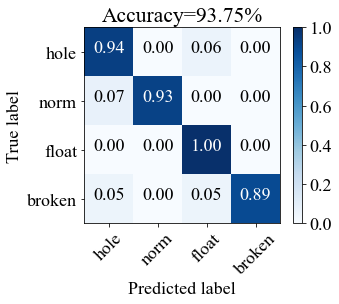

In [4]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(labels.data, preds)
plt.figure()
plot_confusion_matrix(cnf_matrix, ['hole','norm','float','broken'],normalize=True,title='Accuracy={:.2f}%'.format(accuracy*100),cmap=plt.cm.Blues)